# 01 Equity Risk Premium

**Book:** *Expected Returns* (Ilmanen)  
**Focus:** Build a local-data ERP proxy panel for SPY excess returns conditioned on rates, breakevens, and volatility.

## Proxy Scope And Local-Data Limits

This notebook uses only internal parquet datasets under `data/market_data/`.

1. `SPY` is used as the U.S. equity market proxy.
2. Excess return is approximated using `DGS3MO` as the risk-free proxy (converted to daily carry).
3. Conditioning variables are local proxies: `DGS10`, `T10Y2Y`, `T10YIE`, `BAMLH0A0HYM2`, `^VIX`, and `vix3m_daily`.
4. No dividend futures, buyback flow, option-implied ERP, or long history beyond local parquet coverage is used.
5. Outputs are descriptive scaffolding, not a production ERP model.

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

REPO_ROOT = Path("/Users/zelin/Desktop/PA Investment/Invest_strategy")
STUDY_DIR = REPO_ROOT / "workstation" / "playground" / "studies" / "2026-03-29_expected_returns_ilmanen"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(STUDY_DIR) not in sys.path:
    sys.path.insert(0, str(STUDY_DIR))

from local_parquet import (
    DEFAULT_END,
    DEFAULT_START,
    annualize_rate,
    business_days,
    forward_return,
    load_fred_series,
    load_named_price_series,
    load_price_series,
    read_catalog,
    rolling_zscore,
    simple_returns,
)

START = DEFAULT_START
END = DEFAULT_END
ERP_PANEL_CSV = STUDY_DIR / "01_erp_proxy_panel.csv"
ERP_SUMMARY_CSV = STUDY_DIR / "01_erp_regime_summary.csv"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

catalog = read_catalog()
print("Expected environment: conda activate ibkr-analytics && export PYTHONPATH=.")
print("Study dir:", STUDY_DIR)
print("Start/End:", START, END)
print("Catalog datasets:", sorted(catalog.keys()))

Expected environment: conda activate ibkr-analytics && export PYTHONPATH=.
Study dir: /Users/zelin/Desktop/PA Investment/Invest_strategy/workstation/playground/studies/2026-03-29_expected_returns_ilmanen
Start/End: 2024-02-26 2026-02-27
Catalog datasets: ['commodities', 'equities', 'fed_liquidity', 'fx', 'ibkr_equities', 'ibkr_fx', 'macro_indicators', 'rates_yf', 'treasury_yields']


In [2]:
days = business_days(START, END)

price_panel = load_price_series(["SPY", "^VIX"], start=START, end=END).reindex(days).ffill()
vix3m = load_named_price_series("vix3m_daily", value_col="close", start=START, end=END).reindex(days).ffill()
fred_panel = load_fred_series(["DGS3MO", "DGS10", "T10Y2Y", "T10YIE", "BAMLH0A0HYM2"], start=START, end=END).reindex(days).ffill()

raw_panel = pd.concat([
    price_panel[["SPY", "^VIX"]].rename(columns={"^VIX": "vix"}),
    vix3m.rename("vix3m"),
    fred_panel,
], axis=1)

raw_panel.index.name = "date"
raw_panel.tail()

                   SPY        vix      vix3m  BAMLH0A0HYM2  DGS10  DGS3MO  T10Y2Y  T10YIE
date                                                                                     
2026-02-23  682.390015  21.010000  22.139999          2.95   4.03    3.69    0.60    2.26
2026-02-24  687.349976  19.549999  21.340000          2.97   4.03    3.69    0.61    2.26
2026-02-25  693.150024  19.549999  20.360001          2.94   4.05    3.69    0.60    2.28
2026-02-26  689.299988  18.629999  20.809999          2.98   4.05    3.69    0.60    2.28
2026-02-27  685.989990  19.860001  21.559999          2.98   4.05    3.69    0.59    2.25

In [3]:
erp = raw_panel.copy()

erp["spy_ret_1d"] = simple_returns(erp["SPY"])
erp["rf_daily"] = annualize_rate(erp["DGS3MO"]) / 252.0
erp["erp_excess_1d"] = erp["spy_ret_1d"] - erp["rf_daily"]

erp["spy_fwd_21d"] = forward_return(erp["SPY"], horizon=21)
erp["rf_fwd_21d"] = erp["rf_daily"].rolling(21, min_periods=21).sum().shift(-21)
erp["erp_excess_fwd_21d"] = erp["spy_fwd_21d"] - erp["rf_fwd_21d"]

erp["real_yield_10y_proxy"] = erp["DGS10"] - erp["T10YIE"]
erp["term_slope_2s10s"] = erp["T10Y2Y"]
erp["credit_spread_hy_oas"] = erp["BAMLH0A0HYM2"]
erp["vix_level"] = erp["vix"]
erp["vix_term_premium"] = erp["vix3m"] - erp["vix"]

erp["vix_z_6m"] = rolling_zscore(erp["vix_level"], window=126)
erp["real_yield_z_6m"] = rolling_zscore(erp["real_yield_10y_proxy"], window=126)
erp["credit_z_6m"] = rolling_zscore(erp["credit_spread_hy_oas"], window=126)

erp_model = erp[[
    "SPY",
    "vix",
    "vix3m",
    "DGS3MO",
    "DGS10",
    "T10Y2Y",
    "T10YIE",
    "BAMLH0A0HYM2",
    "erp_excess_1d",
    "erp_excess_fwd_21d",
    "real_yield_10y_proxy",
    "term_slope_2s10s",
    "credit_spread_hy_oas",
    "vix_level",
    "vix_term_premium",
    "vix_z_6m",
    "real_yield_z_6m",
    "credit_z_6m",
]].dropna()

print("Model observations:", len(erp_model))
erp_model.tail()

Model observations: 463


                   SPY        vix      vix3m  DGS3MO  DGS10  T10Y2Y  T10YIE  BAMLH0A0HYM2  erp_excess_1d  erp_excess_fwd_21d  real_yield_10y_proxy  term_slope_2s10s  credit_spread_hy_oas  vix_level  vix_term_premium  vix_z_6m  real_yield_z_6m  credit_z_6m
date                                                                                                                                                                                                                                                           
2026-01-23  689.229980  16.090000  19.150000    3.70   4.24    0.64    2.32          2.68       0.000216           -0.012995                  1.92              0.64                  2.68  16.090000          3.059999 -0.283745         1.106378    -1.578223
2026-01-26  692.729980  16.150000  19.070000    3.67   4.22    0.66    2.32          2.69       0.004932           -0.010838                  1.90              0.66                  2.69  16.150000          2.920000 -0.246823       

In [4]:
predictors = [
    "real_yield_10y_proxy",
    "term_slope_2s10s",
    "credit_spread_hy_oas",
    "vix_level",
    "vix_term_premium",
]

corr_table = erp_model[predictors + ["erp_excess_1d", "erp_excess_fwd_21d"]].corr().round(3)

erp_model["vix_regime"] = pd.qcut(erp_model["vix_level"], q=4, labels=["Q1 low", "Q2", "Q3", "Q4 high"])
erp_model["real_yield_regime"] = pd.qcut(erp_model["real_yield_10y_proxy"], q=4, labels=["Q1 low", "Q2", "Q3", "Q4 high"])

regime_summary = pd.concat([
    erp_model.groupby("vix_regime", observed=False)["erp_excess_fwd_21d"].mean().rename("fwd21_excess_by_vix"),
    erp_model.groupby("real_yield_regime", observed=False)["erp_excess_fwd_21d"].mean().rename("fwd21_excess_by_real_yield"),
], axis=1)

print("Contemporaneous/Predictive Correlation Snapshot")
print(corr_table.loc[predictors, ["erp_excess_1d", "erp_excess_fwd_21d"]].to_string())
regime_summary

Contemporaneous/Predictive Correlation Snapshot
                      erp_excess_1d  erp_excess_fwd_21d
real_yield_10y_proxy          0.026               0.081
term_slope_2s10s             -0.007               0.066
credit_spread_hy_oas         -0.053               0.537
vix_level                    -0.227               0.395
vix_term_premium              0.247              -0.285


         fwd21_excess_by_vix  fwd21_excess_by_real_yield
Q1 low              0.001650                    0.015996
Q2                  0.003291                   -0.002473
Q3                  0.011404                    0.002134
Q4 high             0.023744                    0.024942

saved panel to /Users/zelin/Desktop/PA Investment/Invest_strategy/workstation/playground/studies/2026-03-29_expected_returns_ilmanen/01_erp_proxy_panel.csv
saved regime summary to /Users/zelin/Desktop/PA Investment/Invest_strategy/workstation/playground/studies/2026-03-29_expected_returns_ilmanen/01_erp_regime_summary.csv


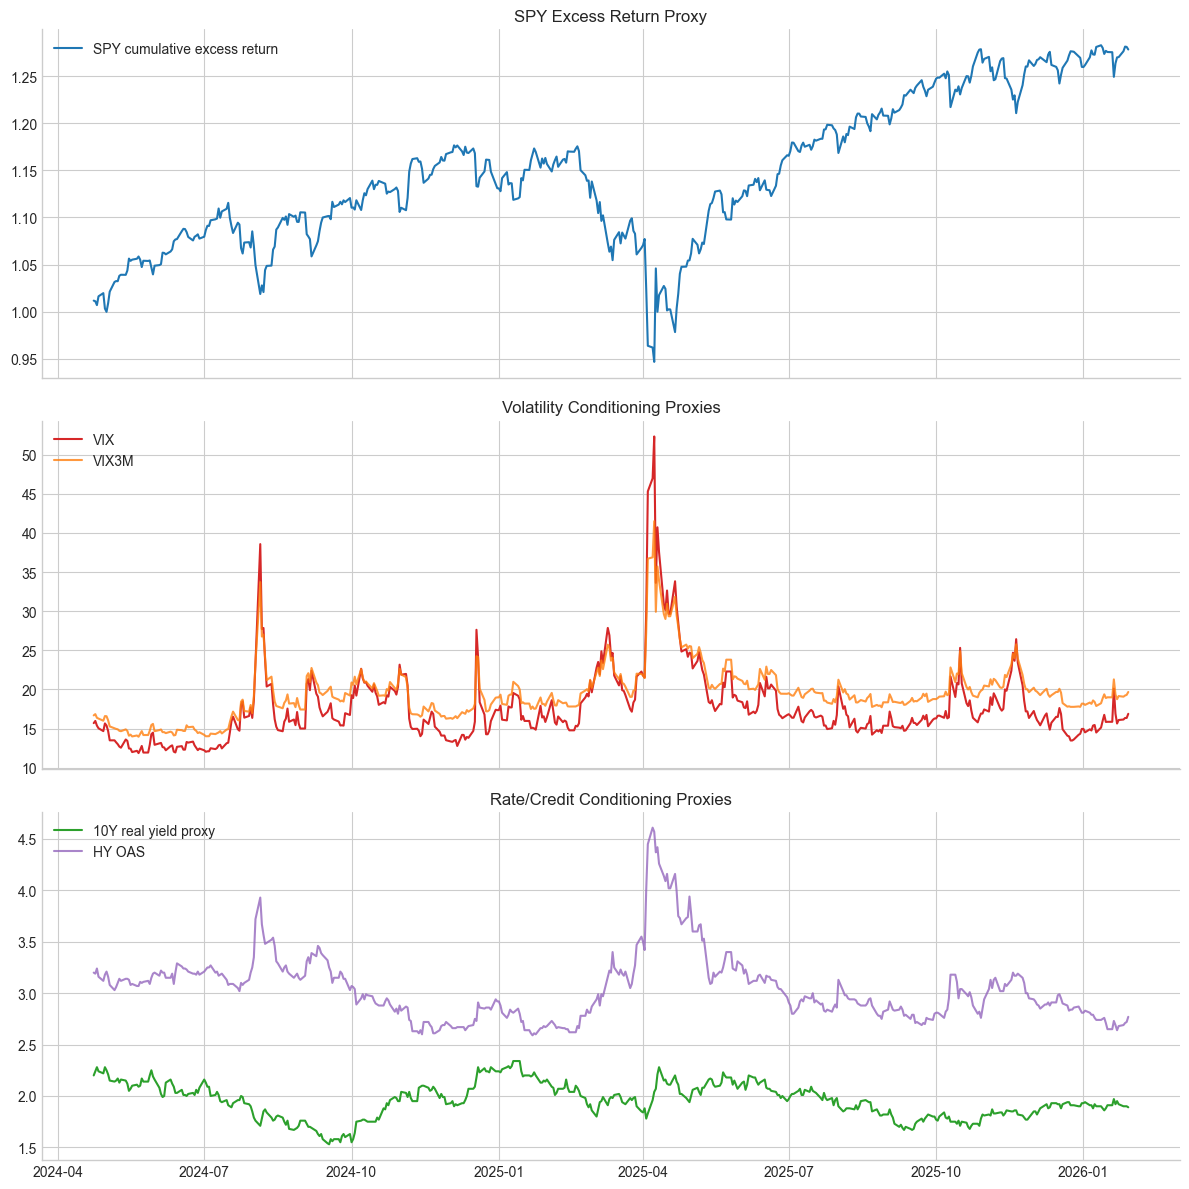

            erp_excess_1d  erp_excess_fwd_21d  vix_level  real_yield_10y_proxy
date                                                                          
2026-01-23       0.000216           -0.012995  16.090000                  1.92
2026-01-26       0.004932           -0.010838  16.150000                  1.90
2026-01-27       0.003839           -0.006437  16.350000                  1.90
2026-01-28      -0.000247           -0.011873  16.350000                  1.90
2026-01-29      -0.002130           -0.014672  16.879999                  1.89

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

cum_excess = (1.0 + erp_model["erp_excess_1d"]).cumprod()
axes[0].plot(cum_excess.index, cum_excess.values, label="SPY cumulative excess return", color="tab:blue")
axes[0].set_title("SPY Excess Return Proxy")
axes[0].legend(loc="upper left")

axes[1].plot(erp_model.index, erp_model["vix_level"], label="VIX", color="tab:red")
axes[1].plot(erp_model.index, erp_model["vix3m"], label="VIX3M", color="tab:orange", alpha=0.8)
axes[1].set_title("Volatility Conditioning Proxies")
axes[1].legend(loc="upper left")

axes[2].plot(erp_model.index, erp_model["real_yield_10y_proxy"], label="10Y real yield proxy", color="tab:green")
axes[2].plot(erp_model.index, erp_model["credit_spread_hy_oas"], label="HY OAS", color="tab:purple", alpha=0.8)
axes[2].set_title("Rate/Credit Conditioning Proxies")
axes[2].legend(loc="upper left")

plt.tight_layout()
plt.show()

erp_model.to_csv(ERP_PANEL_CSV)
regime_summary.to_csv(ERP_SUMMARY_CSV)
print("saved panel to", ERP_PANEL_CSV)
print("saved regime summary to", ERP_SUMMARY_CSV)
erp_model[["erp_excess_1d", "erp_excess_fwd_21d", "vix_level", "real_yield_10y_proxy"]].tail()